In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib

import processing_fun
importlib.reload(processing_fun)

from utils import OperonArgs

# Av

Searching for a function of galaxy properties which is agnostic to dust mixture

Test if Av is exact or inferred

In [9]:
fname = '../data/merged_bestfit_galprops_SMC.dat'
df_fit = pd.read_csv(fname, sep=r'\s+', usecols=["#galaxy_id", "los", "Av"])
df_fit.rename(columns={'#galaxy_id': 'galaxy_id'}, inplace=True)

fname = '../data/gal_los_iobcomp_attcurve_galprop_29_01_SMC.dat'
df_data = pd.read_csv(fname, sep=r'\s+', usecols=["galaxy_id", "los", "A_5542A"])

# Merge the two dataframes on galaxy_id and los
df_merged = pd.merge(df_fit, df_data, on=['galaxy_id', 'los'])

# See if the two equal
print(np.all(df_merged['Av'] == df_merged['A_5542A']))

True


Operon fits


Reading from configuration file: conf/Av_1.ini
Reading from selection file: conf/selection_0.ini

All model lengths:
[ 5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 22 23 24]

Equation requested:
((-1.292664) + ((-1.895993) * ((((-1.378828) * X10) / ((3.565071 * X10) - log((0.997028 * X12)))) + (((-0.037520) * X5) + ((-5.666731) * X6)))))


100%|██████████| 19/19 [00:02<00:00,  6.93it/s]


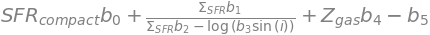


Latex version:
SFR_{compact} b_{0} + \frac{\Sigma_{SFR} b_{1}}{\Sigma_{SFR} b_{2} - \log{\left(b_{3} \sin{\left(i \right)} \right)}} + Z_{gas} b_{4} - b_{5}

Number of parameters: 6
Values: [0.07113765736, 2.614248236204, 3.565071, 0.997028, 10.744082308883, 1.292664]

1 - R2 for chosen model:
Training: 0.2955
Validation: 0.3331

R2 for chosen model:
Training: 0.7045
Validation: 0.6669

Reading from configuration file: conf/Av_1.ini
Reading from selection file: conf/selection_0.ini


(<Figure size 1200x1000 with 4 Axes>,
 array([[<Axes: title={'center': 'log10(Av): Train'}, ylabel='Predicted'>,
         <Axes: title={'center': 'log10(Av): Val'}>],
        [<Axes: xlabel='True', ylabel='Absolute error'>,
         <Axes: xlabel='True'>]], dtype=object))

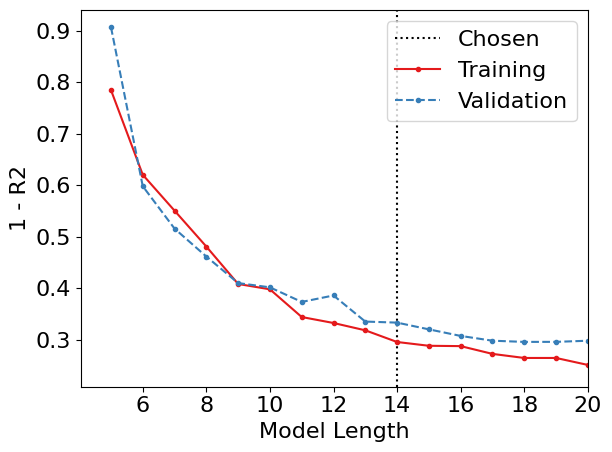

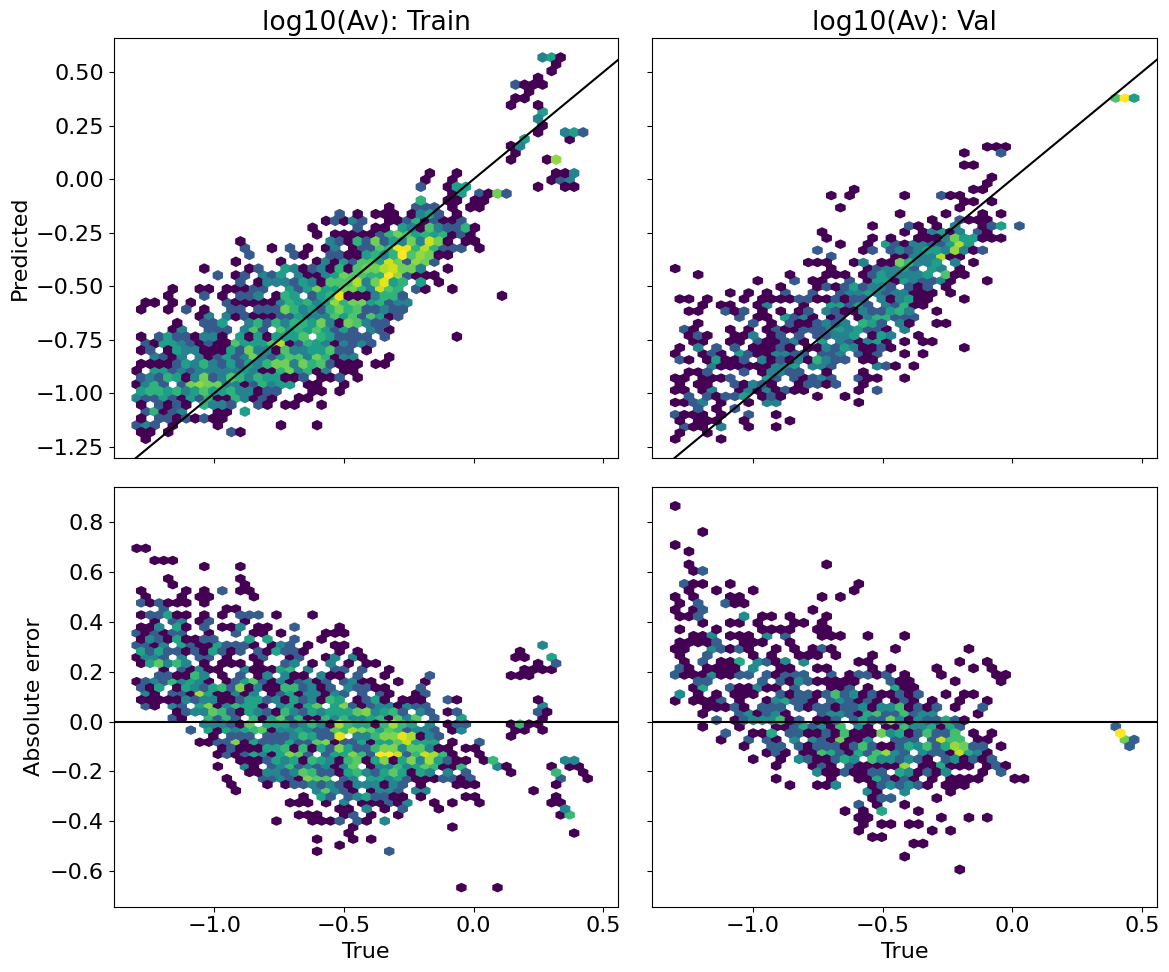

In [4]:
ini_file = 'conf/Av_0.ini'; ilen = 18 #11
ini_file = 'conf/Av_1.ini'; ilen = 14 #13
# ini_file = 'conf/Av_2.ini'; ilen = 17 #13
# ini_file = 'conf/Av_3.ini'; ilen = 14

# I like this one - not the best R2 but relatively simple and still good performance.
# Av_1.ini, ilen=14
# R2 train = 0.7045
# R2 val = 0.6669

# Av_2.ini, ilen=None
# R2 train = 0.7721
# R2 val = 0.7252

# An ok alternative - more complex but better R2
# Av_2.ini, ilen=17
# R2 train = 0.7598
# R2 val = 0.7206

# Another go, but nothing better than above
# Av_3.ini, ilen=14
# R2 train = 0.7015
# R2 val = 0.6722

# CAVEAT: Validation contains some bad LOS for MW dust

processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='linear', loss_max=1.0)
processing_fun.prediction_plots(ini_file, ilen=ilen, frac_error=False)

In [ ]:
fname = 'fits/Av_0/Av_train_7.csv'
ytrue, ypred = np.loadtxt(fname, usecols=(-2, -1), unpack=True)
plt.hist(np.log(ytrue), bins=20, alpha=0.5, label='True')

# $B_0$

Searching for a function of other fit parameters specific to a given dust mixture

## MW dust


Reading from configuration file: conf/B0_6.ini
Reading from selection file: conf/selection_8.ini

All model lengths:
[ 5  7  9 11 13 14 15 16 17 18 19 20 21 22 23 24]

Equation requested:
((-0.051355) + (0.999988 * ((((0.031776 * X3) ^ ((-0.046477) * X2)) * (0.179264 * X2)) + ((-1.227334) * X1))))


  0%|          | 0/16 [00:00<?, ?it/s]

100%|██████████| 16/16 [00:00<00:00, 114.30it/s]



Latex version:
- B_{1s} b_{0} + B_{3} b_{1} \left(A_{V} b_{2}\right)^{- B_{3} b_{3}} - b_{4}

Number of parameters: 5
Values: [1.227319271992, 0.179261848832, 0.031776, 0.046477, 0.051355]

1 - R2 for chosen model:
Training: 0.0812
Validation: 0.1071

R2 for chosen model:
Training: 0.9188
Validation: 0.8929


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Model Length', ylabel='1 - R2'>)

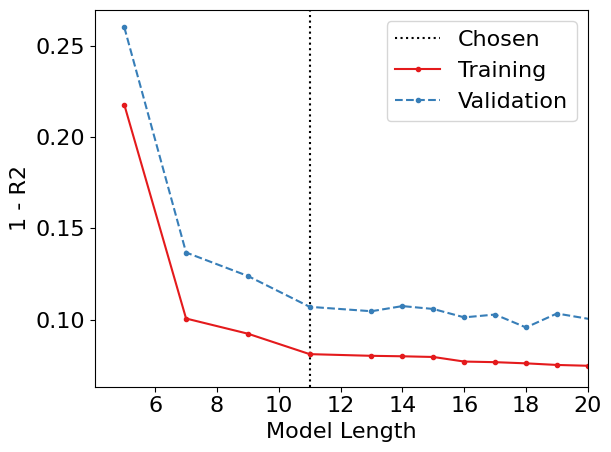

In [ ]:
ini_file = 'conf/B0_0.ini'; ilen = 16
ini_file = 'conf/B0_3.ini'; ilen = 13

# These runs don't depend on B2
ini_file = 'conf/B0_6.ini'; ilen = 11
# ini_file = 'conf/B0_9.ini'; ilen = None

# _0 and _3 have almost identical R2. B0_0 is simple after simplifying the log,
# although maybe a risk of a negative argument to the log?
# Since B3>=0 and Av >=0, the bases of powers for the B0_3
# expression are always positive - safer choice

# B0_0.ini, ilen = 16
# R2 train = 0.9318
# R2 val = 0.9240

# B0_3.ini, ilen = 13
# R2 train = 0.9312
# R2 val = 0.9204

# B0_6.ini, ilen = 11
# R2 train = 0.9188
# R2 val = 0.8929

# NOTE: Almost no improvement in R2 if adding B2, so probably best to ignore it and just use B1, B3 and Av.

importlib.reload(processing_fun)
processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='linear', loss_max=1.0)

## SMC dust


Reading from configuration file: conf/B0_7.ini
Reading from selection file: conf/selection_9.ini

All model lengths:
[ 5  7  9 11 13 14 15 17 18 19 20 21 22 23 24]

Equation requested:
(0.001294 + (1.006405 * ((((0.000212 * X2) ^ ((8.969960 * X3) ^ ((-3.325342) * X1))) + (((0.155770 * X2) ^ (39.676514 * X2)) / (((0.155198 * X2) ^ (38.003082 * X2)) + ((15.437711 * X3) ^ (127.222099 * X1))))) * log((19.375650 * X3)))))


100%|██████████| 15/15 [00:00<00:00, 196.74it/s]


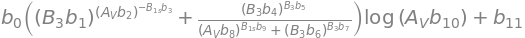


Latex version:
b_{0} \left(\left(B_{3} b_{1}\right)^{\left(A_{V} b_{2}\right)^{- B_{1s} b_{3}}} + \frac{\left(B_{3} b_{4}\right)^{B_{3} b_{5}}}{\left(A_{V} b_{8}\right)^{B_{1s} b_{9}} + \left(B_{3} b_{6}\right)^{B_{3} b_{7}}}\right) \log{\left(A_{V} b_{10} \right)} + b_{11}

Number of parameters: 12
Values: [1.006405, 0.000212, 8.96996, 3.325342, 0.15577, 39.676514, 0.155198, 38.003082, 15.437711, 127.222099, 19.37565, 0.001294]

1 - R2 for chosen model:
Training: 0.0767
Validation: nan

R2 for chosen model:
Training: 0.9233
Validation: nan


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Model Length', ylabel='1 - R2'>)

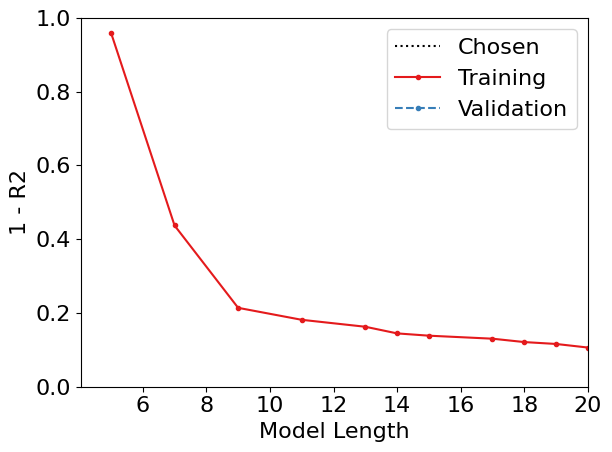

In [25]:
ini_file = 'conf/B0_1.ini'; ilen = None
ini_file = 'conf/B0_4.ini'; ilen = None

# These runs don't depend on B2
ini_file = 'conf/B0_7.ini'; ilen = None
# ini_file = 'conf/B0_10.ini'; ilen = None

importlib.reload(processing_fun)
processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='linear', loss_max=1.0)
# processing_fun.prediction_plots(ini_file, ilen=ilen, frac_error=False)

## Stellar dust


Reading from configuration file: conf/B0_8.ini
Reading from selection file: conf/selection_10.ini

All model lengths:
[ 5  7  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]

Equation requested:
((-0.001000) + (1.029258 * ((((0.184567 * X2) + ((-0.780814) * X1)) * ((17.699478 * X3) * ((0.681940 * X1) + ((0.161576 * X2) ^ (((0.139498 * X2) ^ ((-20.978931) * X1)) + log((3.427239 * X2))))))) ^ (2.238508 + ((-1.599820) * X1)))))


  0%|          | 0/18 [00:00<?, ?it/s]

100%|██████████| 18/18 [00:00<00:00, 212.50it/s]



Latex version:
b_{0} \left(A_{V} b_{1} \left(- B_{1s} b_{2} + B_{3} b_{3}\right) \left(B_{1s} b_{4} + \left(B_{3} b_{5}\right)^{\log{\left(B_{3} b_{6} \right)} + \left(B_{3} b_{7}\right)^{- B_{1s} b_{8}}}\right)\right)^{- B_{1s} b_{10} + b_{9}} - b_{11}

Number of parameters: 12
Values: [1.029258, 17.699478, 0.780814, 0.184567, 0.68194, 0.161576, 3.427239, 0.139498, 20.978931, 2.238508, 1.59982, 0.001]

1 - R2 for chosen model:
Training: 0.2501
Validation: 0.5839

R2 for chosen model:
Training: 0.7499
Validation: 0.4161


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Model Length', ylabel='1 - R2'>)

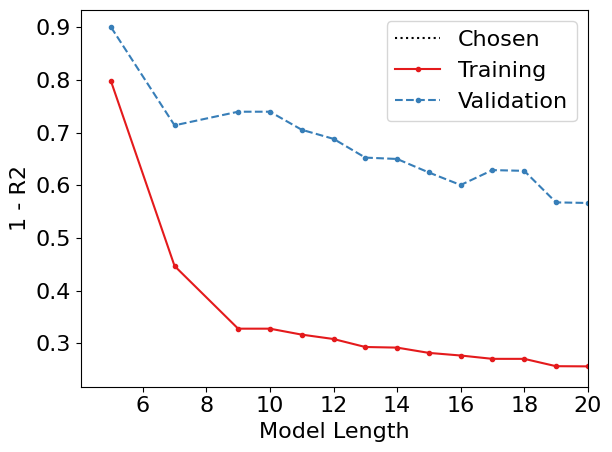

In [23]:
ini_file = 'conf/B0_2.ini'; ilen = 15
# ini_file = 'conf/B0_5.ini'; ilen = None

# These runs don't depend on B2
ini_file = 'conf/B0_8.ini'; ilen = None
# ini_file = 'conf/B0_11.ini'; ilen = None

importlib.reload(processing_fun)
processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='linear', loss_max=1.0)
# processing_fun.prediction_plots(ini_file, ilen=ilen, frac_error=False)

# $B_1$

Searching for a function of galaxy properties and $A_{\rm V}$ which is agnostic to dust mixture


Reading from configuration file: conf/B1_0.ini
Reading from selection file: conf/selection_1.ini

All model lengths:
[ 5  6  7  9 11 12 13 14 15 16 17 18 19 20 21 22 23 24]

Equation requested:
(0.038551 + (0.739108 * (log(((0.152161 * X7) + (78.675392 * X6))) * ((((-4.000157) * X5) / ((-6.794852) * X4)) ^ (9.964625 * X12)))))


  0%|          | 0/18 [00:00<?, ?it/s]

100%|██████████| 18/18 [00:00<00:00, 105.71it/s]


Latex version:
b_{0} \left(\frac{SFR_{compact} b_{1}}{SFR}\right)^{A_{V} b_{2}} \log{\left(R_{star} b_{3} + Z_{gas} b_{4} \right)} + b_{5}

Number of parameters: 6
Values: [0.739108, 0.588704065960524, 9.964625, 0.152161, 78.675392, 0.038551]

1 - R2 for chosen model:
Training: 0.3055
Validation: 0.2667

R2 for chosen model:
Training: 0.6945
Validation: 0.7333

Reading from configuration file: conf/B1_0.ini
Reading from selection file: conf/selection_1.ini


(<Figure size 1200x1000 with 4 Axes>,
 array([[<Axes: title={'center': 'B_1s: Train'}, ylabel='Predicted'>,
         <Axes: title={'center': 'B_1s: Val'}>],
        [<Axes: xlabel='True', ylabel='Absolute error'>,
         <Axes: xlabel='True'>]], dtype=object))

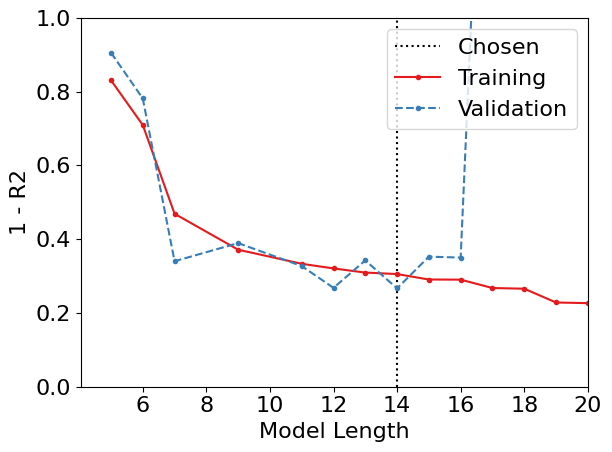

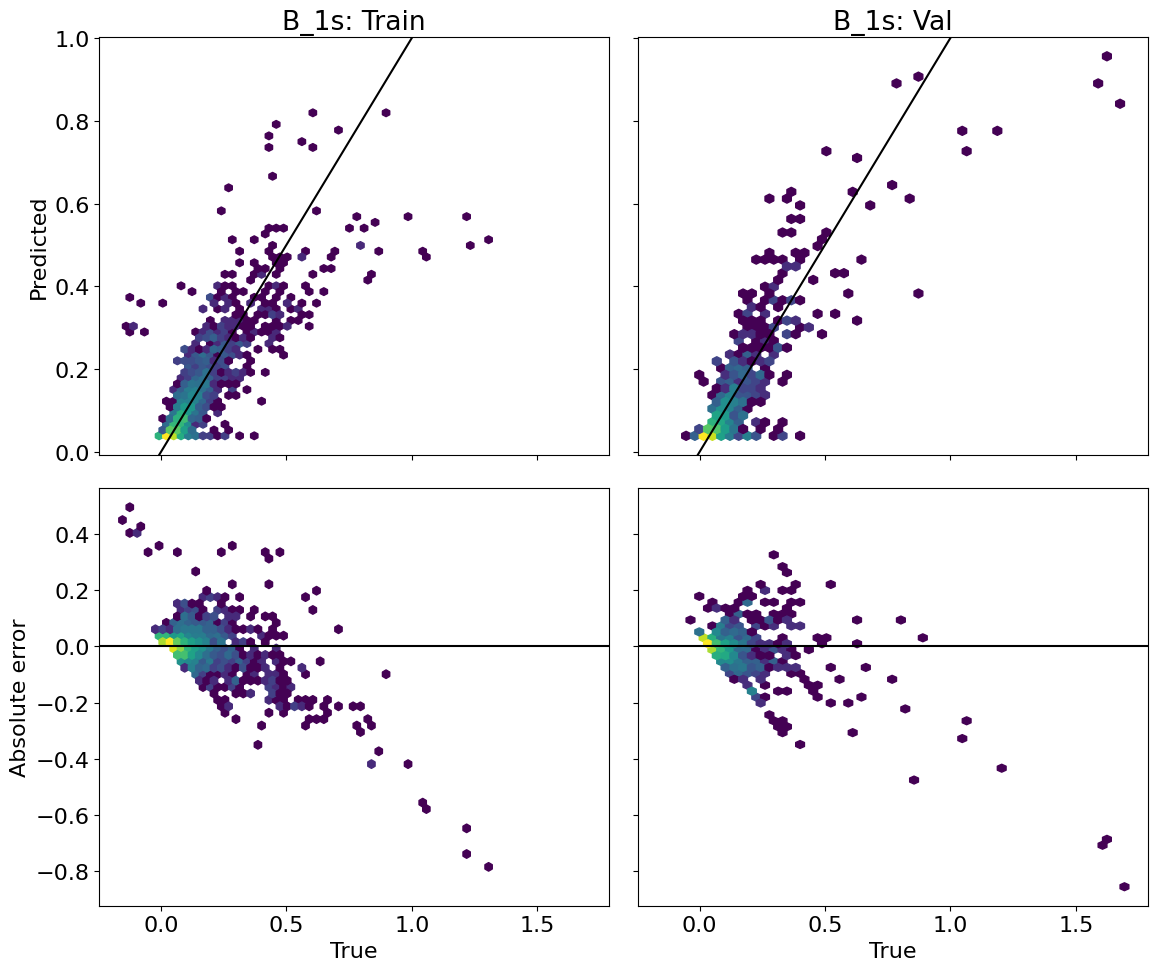

In [ ]:
ini_file = 'conf/B1_0.ini'; ilen = 14
# ini_file = 'conf/B1_1.ini'; ilen = 11
# ini_file = 'conf/B1_2.ini'; ilen = 15

# Both of the below behave comparably and both are relatively simple

# B1_0.ini, ilen=14
# R2 train = 0.6945
# R2 val = 0.7333

# B1_2.ini, ilen=15
# R2 train = 0.6909
# R2 val = 0.7810

processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='linear', loss_max=1.0)
processing_fun.prediction_plots(ini_file, ilen=ilen, frac_error=False)

In [ ]:
fname = 'fits/B_1s_0/B_1s_train_9.csv'
ytrue, ypred = np.loadtxt(fname, usecols=(-2, -1), unpack=True)
bins = np.linspace(-0.5, 0.5, 20)
plt.hist(ytrue, bins=bins, alpha=0.5, label='True')

# $B_2$

Searching for a function of other fit parameters specific to a given dust mixture

## MW dust


Reading from configuration file: conf/B2_6.ini
Reading from selection file: conf/selection_5.ini

All model lengths:
[ 5  7  9 10 11 12 13 15 16 17 19 21 23]

Equation requested:
((-0.138358) + (1.209563 * ((0.549841 ^ ((0.168405 * X2) ^ (11.411837 * X1))) * (((2.915770 * X3) ^ ((-0.127699) * X2)) + ((-5.969034) * X1)))))


  0%|          | 0/13 [00:00<?, ?it/s]

100%|██████████| 13/13 [00:00<00:00, 218.34it/s]



Latex version:
b_{0} b_{1}^{\left(B_{3} b_{2}\right)^{B_{1s} b_{3}}} \left(- B_{1s} b_{4} + \left(A_{V} b_{5}\right)^{- B_{3} b_{6}}\right) - b_{7}

Number of parameters: 8
Values: [1.209563, 0.549841, 0.168405, 11.411837, 5.969034, 2.91577, 0.127699, 0.138358]

1 - R2 for chosen model:
Training: 0.5880
Validation: 0.6227

R2 for chosen model:
Training: 0.4120
Validation: 0.3773


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Model Length', ylabel='1 - R2'>)

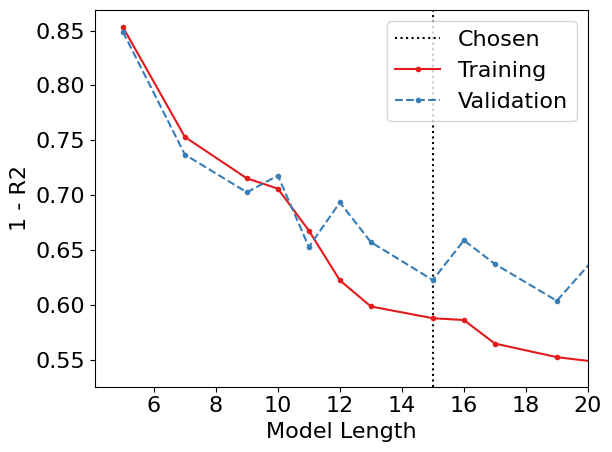

In [ ]:
ini_file = 'conf/B2_0.ini'; ilen = 15
# ini_file = 'conf/B2_3.ini'; ilen = 15

# These runs don't depend on B0
ini_file = 'conf/B2_6.ini'; ilen = 15
# ini_file = 'conf/B2_9.ini'; ilen = None

# B2_0.ini, ilen=15
# R2 train = 0.4119
# R2 val = 0.3769

# B2_3.ini, ilen=15
# R2 train = 0.4172
# R2 val = 0.3887

# B2_6.ini, ilen=15
# R2 train = 0.4120
# R2 val = 0.3773

# NOTE: Almost no improvement in R2 if adding B0, so probably best to ignore it and just use B1, B3 and Av.

importlib.reload(processing_fun)
processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='linear', loss_max=1.0)

## SMC dust


Reading from configuration file: conf/B2_7.ini
Reading from selection file: conf/selection_6.ini

All model lengths:
[ 5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 23 24]

Equation requested:
(8.631315 + ((-8.802770) * ((0.775352 * X3) ^ ((-0.014711) * X2))))


  0%|          | 0/19 [00:00<?, ?it/s]

100%|██████████| 19/19 [00:00<00:00, 228.24it/s]



Latex version:
b_{0} - b_{1} \left(A_{V} b_{2}\right)^{- B_{3} b_{3}}

Number of parameters: 4
Values: [8.631315, 8.80277, 0.775352, 0.014711]

1 - R2 for chosen model:
Training: 0.5494
Validation: 0.8774

R2 for chosen model:
Training: 0.4506
Validation: 0.1226


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Model Length', ylabel='1 - R2'>)

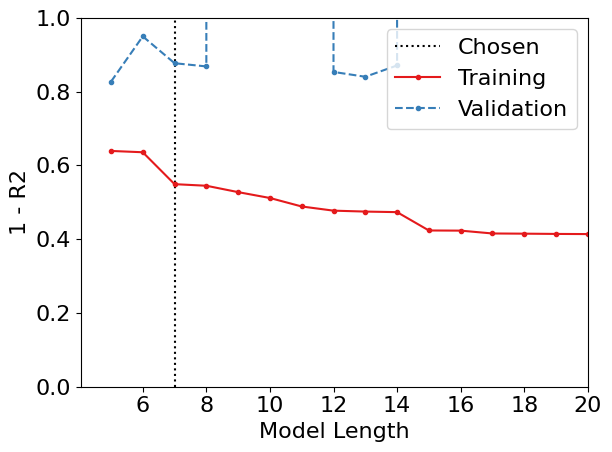

In [ ]:
ini_file = 'conf/B2_1.ini'; ilen = 8
ini_file = 'conf/B2_4.ini'; ilen = 8

# These runs don't depend on B0
ini_file = 'conf/B2_7.ini'; ilen = 7
# ini_file = 'conf/B2_10.ini'; ilen = None

importlib.reload(processing_fun)
processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='linear', loss_max=1.0)

## Stellar dust


Reading from configuration file: conf/B2_8.ini
Reading from selection file: conf/selection_7.ini

All model lengths:
[ 5  7  9 11 12 14 15 16 17 18 19 20 21 22 23 24]

Equation requested:
(0.036451 + (1.002164 * ((((-12.051348) * X1) + (0.140445 * X2)) - (((-12.558363) * X1) * ((((-0.369027) * X1) + (0.221180 * X2)) * (((0.236475 * X2) + (0.460091 * X3)) ^ ((-2.997129) * X3)))))))


  0%|          | 0/16 [00:00<?, ?it/s]

100%|██████████| 16/16 [00:00<00:00, 199.59it/s]



Latex version:
- B_{1s} b_{0} + B_{1s} b_{1} \left(A_{V} b_{4} + B_{3} b_{5}\right)^{- A_{V} b_{6}} \left(- B_{1s} b_{2} + B_{3} b_{3}\right) + B_{3} b_{7} + b_{8}

Number of parameters: 9
Values: [12.077427117072, 12.585539297532, 0.369027, 0.22118, 0.460091, 0.236475, 2.997129, 0.14074892298, 0.036451]

1 - R2 for chosen model:
Training: 0.5992
Validation: 0.5324

R2 for chosen model:
Training: 0.4008
Validation: 0.4676


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Model Length', ylabel='1 - R2'>)

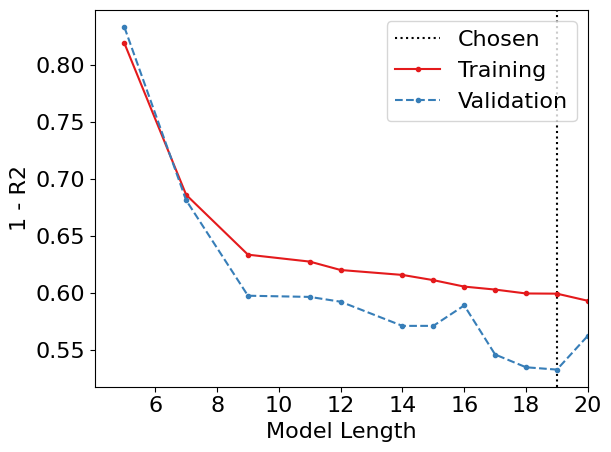

In [ ]:
ini_file = 'conf/B2_2.ini'; ilen = 15
ini_file = 'conf/B2_5.ini'; ilen = 15

# These runs don't depend on B0
ini_file = 'conf/B2_8.ini'; ilen = 19
# ini_file = 'conf/B2_11.ini'; ilen = None

# B2_2.ini, ilen=15
# R2 train = 0.4460
# R2 val = 0.5267

# B2_5.ini, ilen=15
# R2 train = 0.4459
# R2 val = 0.5263

# B2_8.ini, ilen=15
# R2 train = 0.4008
# R2 val = 0.4676

# Slight drop if B0 ignored

importlib.reload(processing_fun)
processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='linear', loss_max=1.0)

# $B_3$

Searching for a function of galaxy properties and $A_{\rm V}$ which is agnostic to dust mixture


Reading from configuration file: conf/B3_0.ini
Reading from selection file: conf/selection_1.ini

All model lengths:
[ 5  6  7  8  9 10 11 13 14 16 17 18 19 20 21 22 24]

Equation requested:
(0.175270 + (34.387421 * ((1714.031738 * X12) ^ ((((-9.949830) * X5) + (284.764496 * X11)) / ((-45.930786) * X4)))))


  0%|          | 0/17 [00:00<?, ?it/s]

100%|██████████| 17/17 [00:00<00:00, 163.29it/s]


Latex version:
b_{0} + b_{1} \left(A_{V} b_{2}\right)^{- \frac{b_{3} \left(- SFR_{compact} b_{4} + b_{5} sSFR\right)}{SFR}}

Number of parameters: 6
Values: [0.17527, 34.387421, 1714.031738, 0.0217718895557328, 9.94983, 284.764496]

1 - R2 for chosen model:
Training: 0.2974
Validation: 0.3495

R2 for chosen model:
Training: 0.7026
Validation: 0.6505

Reading from configuration file: conf/B3_0.ini
Reading from selection file: conf/selection_1.ini


(<Figure size 1200x1000 with 4 Axes>,
 array([[<Axes: title={'center': 'B_3: Train'}, ylabel='Predicted'>,
         <Axes: title={'center': 'B_3: Val'}>],
        [<Axes: xlabel='True', ylabel='Absolute error'>,
         <Axes: xlabel='True'>]], dtype=object))

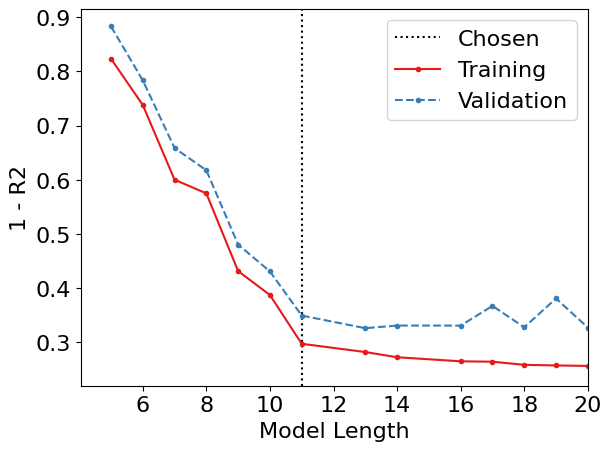

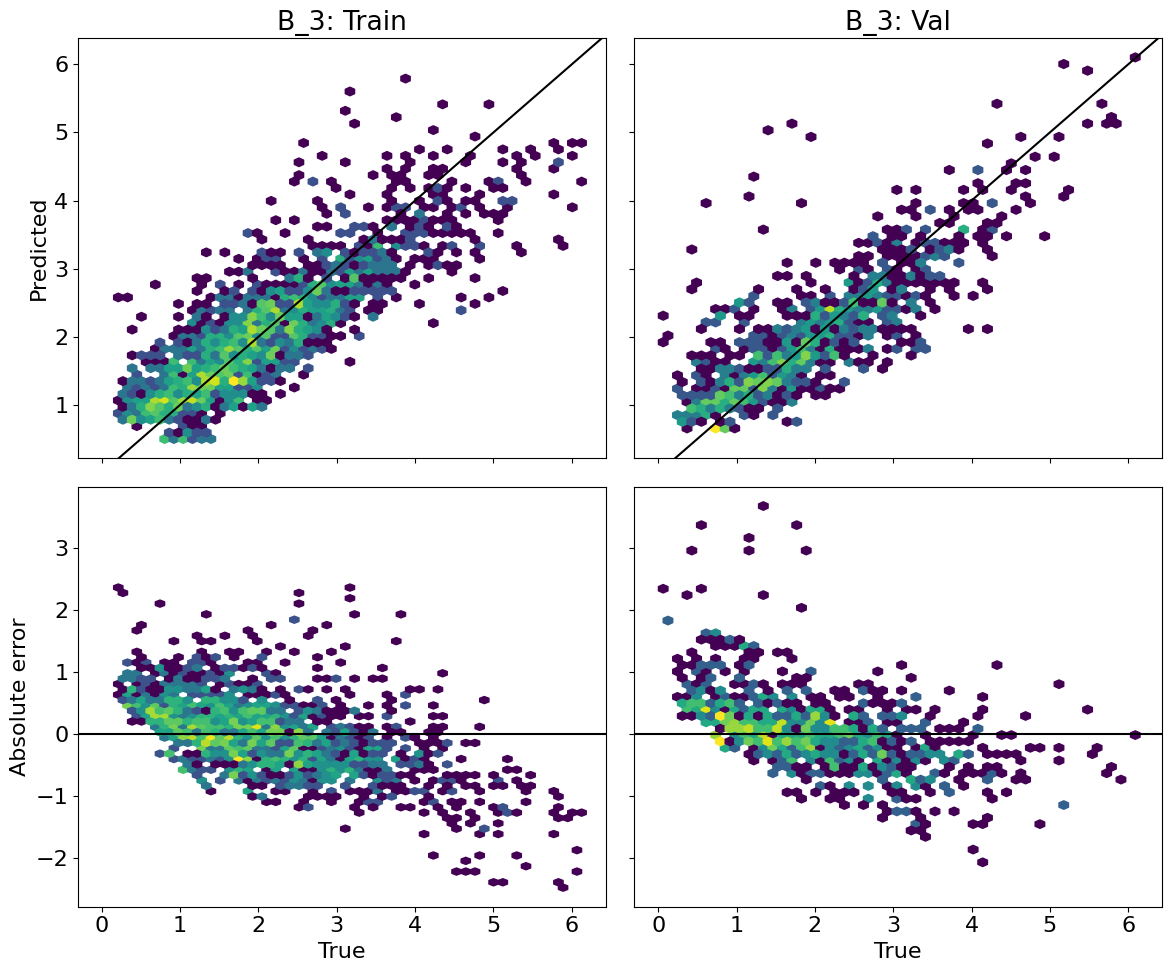

In [26]:
ini_file = 'conf/B3_0.ini'; ilen = 11
# ini_file = 'conf/B3_1.ini'; ilen = 13
# ini_file = 'conf/B3_2.ini'; ilen = 11

# B3_0 and B3_2 are very similar expressions
# Worried that based of expression for B3_1 could be negative - problems raising to a power
# B3_0 seems the best of the three

# B3_0.ini, ilen=11
# R2 train = 0.7026
# R2 val = 0.6505

# B3_1.ini, ilen=13
# R2 train = 0.7104
# R2 val = 0.6683

# B3_2.ini, ilen=11
# R2 train = 0.6820
# R2 val = 0.6424


processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='linear', loss_max=1.0)
processing_fun.prediction_plots(ini_file, ilen=ilen, frac_error=False)